In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


In [3]:
df  = pd.read_csv("insurencee.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,60.0,male,35.9,4.0,yes,southwest,29901.03
1,24.0,male,35.1,1.0,no,northwest,6724.72
2,18.0,female,19.2,2.0,no,southeast,NaN
3,41.0,female,19.6,1.0,yes,northwest,24725.52
4,63.0,female,NaN,3.0,no,southeast,9974.28
...,...,...,...,...,...,...,...
995,28.0,male,24.7,2.0,yes,northwest,NaN
996,22.0,male,35.1,3.0,no,southeast,9148.82
997,45.0,male,29.7,2.0,no,northwest,7806.73
998,46.0,female,28.6,3.0,yes,northwest,28792.48


EDA

In [5]:
df.shape # it shows the actual shape of data 

(1000, 7)

In [6]:
df.head() # it shows top 5 row

,age,sex,bmi,children,smoker,region,charges
0,60.0,male,35.9,4.0,yes,southwest,29901.03
1,24.0,male,35.1,1.0,no,northwest,6724.72
2,18.0,female,19.2,2.0,no,southeast,NaN
3,41.0,female,19.6,1.0,yes,northwest,24725.52
4,63.0,female,NaN,3.0,no,southeast,9974.28


In [7]:
df.info() # it tell about data or its type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       950 non-null    float64
 1   sex       950 non-null    object 
 2   bmi       950 non-null    float64
 3   children  950 non-null    float64
 4   smoker    950 non-null    object 
 5   region    950 non-null    object 
 6   charges   950 non-null    float64
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


In [8]:
df.describe() # it tell about mean max cont etc 

,age,bmi,children,charges
count,950.000000,950.000000,950.000000,950.000000
mean,41.212632,28.741263,2.523158,18640.234547
std,14.011626,6.322473,1.708156,9211.086009
min,18.000000,18.000000,0.000000,3989.960000
25%,29.000000,23.400000,1.000000,9495.780000
50%,41.000000,28.500000,3.000000,23434.630000
75%,53.750000,34.200000,4.000000,27546.587500
max,65.000000,40.000000,5.000000,32713.460000


In [9]:
df.isnull().sum() # it tell total null value in dataset

age         50
sex         50
bmi         50
children    50
smoker      50
region      50
charges     50
dtype: int64

In [10]:
df['age'] = df['age'].fillna(df['age'].mean())

df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
df['children'] = df['children'].fillna(df['children'].mean())
df['smoker'] = df['smoker'].fillna(df['smoker'].mode()[0])
df['region'] = df['region'].fillna(df['region'].mode()[0])
df['charges'] = df['charges'].fillna(df['charges'].mean())
df.isnull().sum()

age          0
sex         50
bmi          0
children     0
smoker       0
region       0
charges      0
dtype: int64

In [11]:

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])


In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

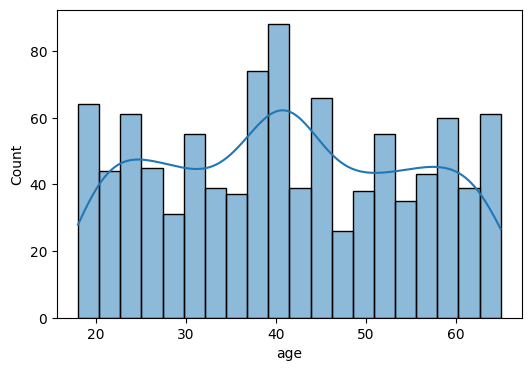

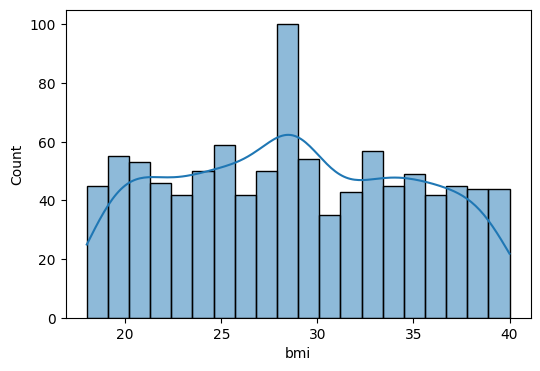

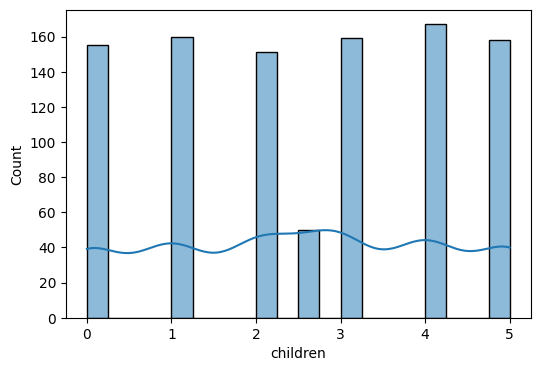

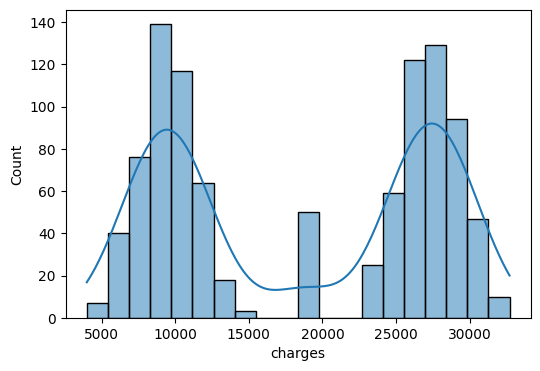

In [13]:
numeric_columns = ['age' , 'bmi' , 'children' , 'charges' ]
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, bins =20)

<Axes: xlabel='children', ylabel='count'>

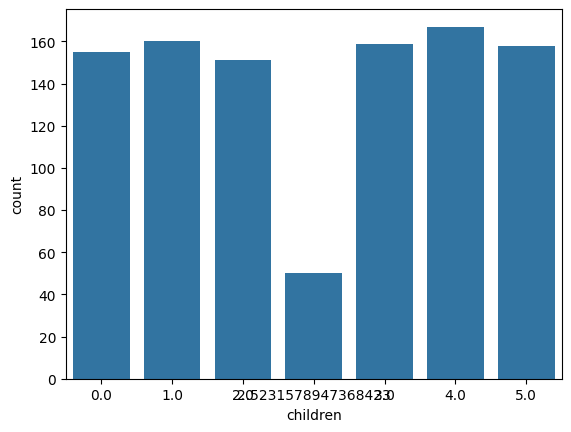

In [14]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

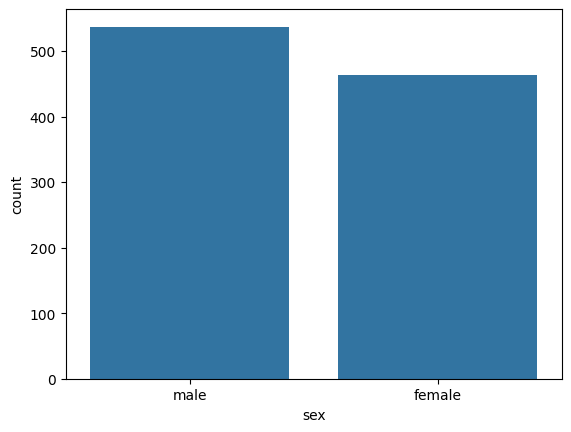

In [15]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

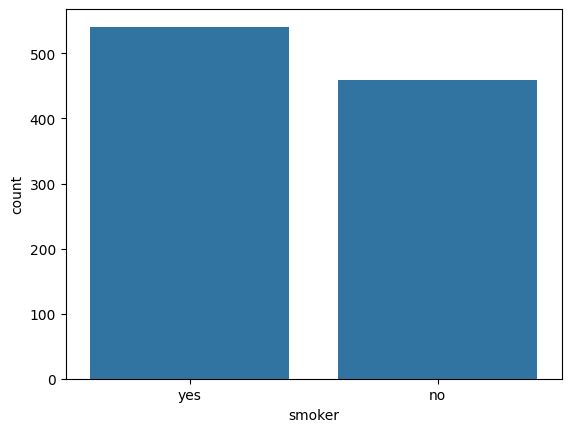

In [16]:
sns.countplot(x = df['smoker'])

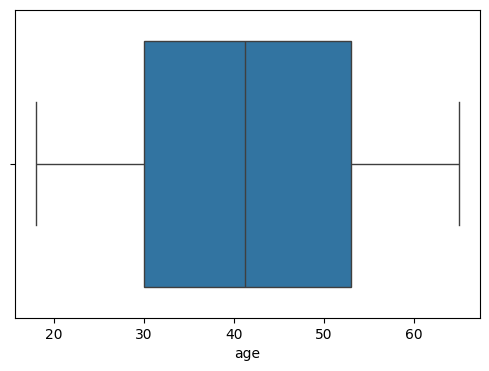

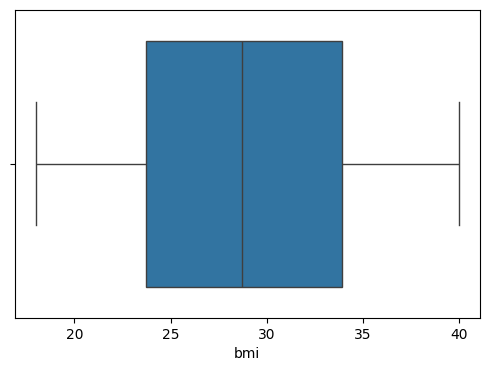

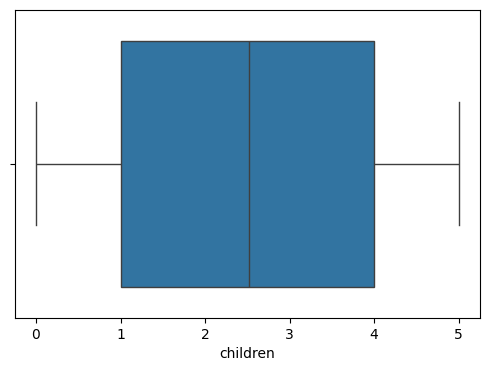

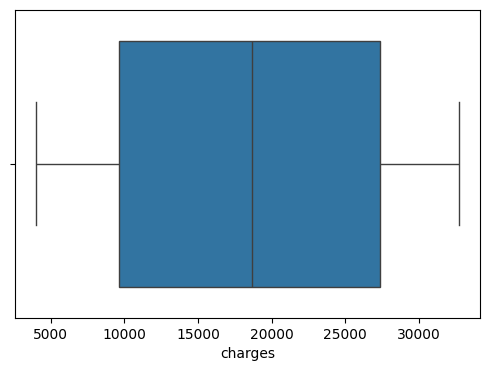

In [17]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x= df[col])

<Axes: >

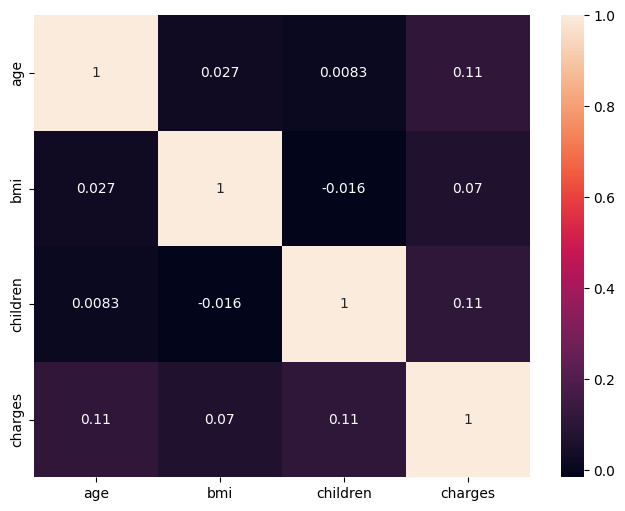

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only =True ), annot =True )

Data Cleaning and Preprocessing

In [19]:
df_cleaned =df.copy()

In [20]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,60.0,male,35.900000,4.0,yes,southwest,29901.030000
1,24.0,male,35.100000,1.0,no,northwest,6724.720000
2,18.0,female,19.200000,2.0,no,southeast,18640.234547
3,41.0,female,19.600000,1.0,yes,northwest,24725.520000
4,63.0,female,28.741263,3.0,no,southeast,9974.280000


In [21]:
df_cleaned.shape

(1000, 7)

In [22]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
df_cleaned.drop_duplicates(inplace=True)

In [24]:
df_cleaned.shape

(1000, 7)

In [25]:
df_cleaned.dtypes

age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges     float64
dtype: object

In [26]:
df_cleaned['sex'].value_counts()

sex
male      537
female    463
Name: count, dtype: int64

In [27]:
df_cleaned['sex'] =df_cleaned['sex'].map({"male" :1, "female" :0})

In [28]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,60.0,1,35.900000,4.0,yes,southwest,29901.030000
1,24.0,1,35.100000,1.0,no,northwest,6724.720000
2,18.0,0,19.200000,2.0,no,southeast,18640.234547
3,41.0,0,19.600000,1.0,yes,northwest,24725.520000
4,63.0,0,28.741263,3.0,no,southeast,9974.280000


In [29]:
df_cleaned['smoker'].value_counts()

smoker
yes    541
no     459
Name: count, dtype: int64

Labal encoding

In [30]:
df_cleaned['smoker'] =df_cleaned['smoker'].map({"yes":1, "no":0})

In [31]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,60.0,1,35.900000,4.0,1,southwest,29901.030000
1,24.0,1,35.100000,1.0,0,northwest,6724.720000
2,18.0,0,19.200000,2.0,0,southeast,18640.234547
3,41.0,0,19.600000,1.0,1,northwest,24725.520000
4,63.0,0,28.741263,3.0,0,southeast,9974.280000


One Hot Encoding

In [32]:
df_cleaned.rename(columns={
    'sex' : 'is_male',
    'smoker': 'is_smoker'
}
                  , inplace=True)

In [33]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,region,charges
0,60.0,1,35.900000,4.0,1,southwest,29901.030000
1,24.0,1,35.100000,1.0,0,northwest,6724.720000
2,18.0,0,19.200000,2.0,0,southeast,18640.234547
3,41.0,0,19.600000,1.0,1,northwest,24725.520000
4,63.0,0,28.741263,3.0,0,southeast,9974.280000


In [34]:
df['region'].value_counts()

region
northeast    303
northwest    244
southeast    227
southwest    226
Name: count, dtype: int64

One hot encoding

In [35]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True)

In [36]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,60.0,1,35.900000,4.0,1,29901.030000,False,False,True
1,24.0,1,35.100000,1.0,0,6724.720000,True,False,False
2,18.0,0,19.200000,2.0,0,18640.234547,False,True,False
3,41.0,0,19.600000,1.0,1,24725.520000,True,False,False
4,63.0,0,28.741263,3.0,0,9974.280000,False,True,False


In [37]:
df_cleaned.columns

Index(['age', 'is_male', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [38]:
df_cleaned = df_cleaned.astype(int)


In [39]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,60,1,35,4,1,29901,0,0,1
1,24,1,35,1,0,6724,1,0,0
2,18,0,19,2,0,18640,0,1,0
3,41,0,19,1,1,24725,1,0,0
4,63,0,28,3,0,9974,0,1,0
...,...,...,...,...,...,...,...,...,...
995,28,1,24,2,1,18640,1,0,0
996,22,1,35,3,0,9148,0,1,0
997,45,1,29,2,0,7806,1,0,0
998,46,0,28,3,1,28792,1,0,0


Feature Engineering and exctrion

<Axes: xlabel='bmi', ylabel='Count'>

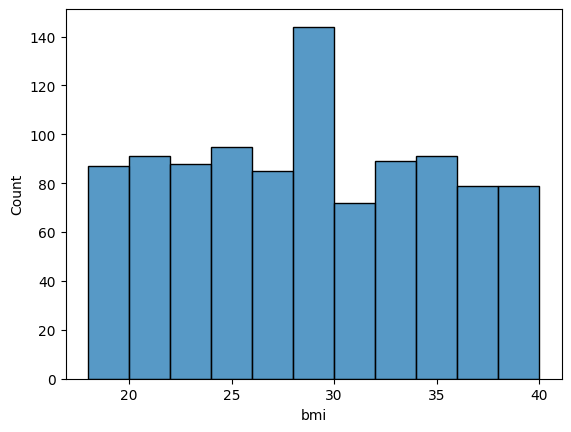

In [40]:
sns.histplot(df['bmi'])

In [41]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [42]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,60,1,35,4,1,29901,0,0,1,Obese
1,24,1,35,1,0,6724,1,0,0,Obese
2,18,0,19,2,0,18640,0,1,0,Normal
3,41,0,19,1,1,24725,1,0,0,Normal
4,63,0,28,3,0,9974,0,1,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
995,28,1,24,2,1,18640,1,0,0,Normal
996,22,1,35,3,0,9148,0,1,0,Obese
997,45,1,29,2,0,7806,1,0,0,Overweight
998,46,0,28,3,1,28792,1,0,0,Overweight


One hot encoding 

In [43]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)

In [44]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,60,1,35,4,1,29901,0,0,1,False,False,True
1,24,1,35,1,0,6724,1,0,0,False,False,True
2,18,0,19,2,0,18640,0,1,0,True,False,False
3,41,0,19,1,1,24725,1,0,0,True,False,False
4,63,0,28,3,0,9974,0,1,0,False,True,False


In [45]:
df_cleaned = df_cleaned.astype(int)

In [46]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,60,1,35,4,1,29901,0,0,1,0,0,1
1,24,1,35,1,0,6724,1,0,0,0,0,1
2,18,0,19,2,0,18640,0,1,0,1,0,0
3,41,0,19,1,1,24725,1,0,0,1,0,0
4,63,0,28,3,0,9974,0,1,0,0,1,0


In [47]:
df_cleaned.columns

Index(['age', 'is_male', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [48]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [49]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,1.377170,1,1.092120,0.901117,1,29901,0,0,1,0,0,1
1,-1.260244,1,1.092120,-0.897520,0,6724,1,0,0,0,0,1
2,-1.699814,0,-1.510878,-0.297974,0,18640,0,1,0,1,0,0
3,-0.014799,0,-1.510878,-0.897520,1,24725,1,0,0,1,0,0
4,1.596954,0,-0.046691,0.301571,0,9974,0,1,0,0,1,0


In [51]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_male', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,0.907241
0,age,0.111297
2,children,0.108703
1,bmi,0.071390
10,bmi_category_Obese,0.046251
5,region_northwest,-0.003370
7,region_southwest,-0.007757
8,bmi_category_Normal,-0.011117
9,bmi_category_Overweight,-0.013668
3,is_male,-0.022553


In [53]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}
cat_features = ['is_male', 'is_smoker', 'bmi']

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,811.011057,0.0,Reject Null (Keep Feature)
bmi,165.799191,0.0,Reject Null (Keep Feature)
is_male,0.518874,0.914726,Accept Null (Drop Feature)


In [54]:
final_df = df_cleaned[['age', 'is_male', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [55]:
final_df

,age,is_male,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,1.377170,1,1.092120,0.901117,1,29901,0,1
1,-1.260244,1,1.092120,-0.897520,0,6724,0,1
2,-1.699814,0,-1.510878,-0.297974,0,18640,1,0
3,-0.014799,0,-1.510878,-0.897520,1,24725,0,0
4,1.596954,0,-0.046691,0.301571,0,9974,1,0
...,...,...,...,...,...,...,...,...
995,-0.967198,1,-0.697441,-0.297974,1,18640,0,0
996,-1.406768,1,1.092120,0.301571,0,9148,1,1
997,0.278247,1,0.115996,-0.297974,0,7806,0,0
998,0.351509,0,-0.046691,0.301571,1,28792,0,0


In [56]:
df


,age,sex,bmi,children,smoker,region,charges
0,60.0,male,35.900000,4.0,yes,southwest,29901.030000
1,24.0,male,35.100000,1.0,no,northwest,6724.720000
2,18.0,female,19.200000,2.0,no,southeast,18640.234547
3,41.0,female,19.600000,1.0,yes,northwest,24725.520000
4,63.0,female,28.741263,3.0,no,southeast,9974.280000
...,...,...,...,...,...,...,...
995,28.0,male,24.700000,2.0,yes,northwest,18640.234547
996,22.0,male,35.100000,3.0,no,southeast,9148.820000
997,45.0,male,29.700000,2.0,no,northwest,7806.730000
998,46.0,female,28.600000,3.0,yes,northwest,28792.480000


In [57]:
df['charges'] = df['charges'].fillna(df['charges'].mean())
df

,age,sex,bmi,children,smoker,region,charges
0,60.0,male,35.900000,4.0,yes,southwest,29901.030000
1,24.0,male,35.100000,1.0,no,northwest,6724.720000
2,18.0,female,19.200000,2.0,no,southeast,18640.234547
3,41.0,female,19.600000,1.0,yes,northwest,24725.520000
4,63.0,female,28.741263,3.0,no,southeast,9974.280000
...,...,...,...,...,...,...,...
995,28.0,male,24.700000,2.0,yes,northwest,18640.234547
996,22.0,male,35.100000,3.0,no,southeast,9148.820000
997,45.0,male,29.700000,2.0,no,northwest,7806.730000
998,46.0,female,28.600000,3.0,yes,northwest,28792.480000


In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X= final_df.drop('charges', axis=1)
y = final_df['charges']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=42)

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [63]:
y_pred = model.predict(X_test)

In [64]:
y_pred

array([10495.62150583, 26680.35066154, 25382.20710421, 11171.36053633,
        8452.78990153, 23879.60704799,  8736.19301795, 10230.5033913 ,
        9258.15450302, 10334.51526488, 27868.2962602 , 11666.80209745,
       25764.32498654,  6877.63462034, 10608.76165164,  8437.833617  ,
       22886.97666461,  7675.17069812, 25811.87821988, 13043.87682627])

In [65]:
from sklearn.metrics import r2_score
r2 =r2_score(y_test, y_pred)
r2

0.8408584598612776

Performance Evaluation

In [66]:
n = X_test.shape[0]
p =X_test.shape[1]
adjusted_r2 =1-((1-r2)* (n-1)/(n-p-1))
adjusted_r2

0.7480258947803562